In [4]:
##############
## INITIATE ##
##############

## Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch

## Import modules
from f_wsi_reader import slide_path_to_tiles_at_coordinates
from f_wsi_reader import get_tile_map
from f_wsi_reader import slide_to_tiles_at_coordinates
from f_wsi_reader import read_slide
from f_wsi_reader import get_dimensions
from f_wsi_reader import apply_all_filters
from f_wsi_reader import apply_all_transforms
from f_wsi_reader import reassemble_tiles
from f_wsi_reader import select_patches_on_grid
from f_model_transformer import UNetTransformer as Model
# from f_model import UNet as Model

#
###

In [5]:
#####################################
## FUNCTIONS FOR MODEL APPLICATION ##
#####################################

## numpy_to_device
## Goal:
## Convert a list of numpy arrays to tensors suitable for model input on a specific device.
## Inputs:
## X (list of numpy arrays): List of images in numpy array format.
## device (str): Device for processing.
## Outputs:
## tensors (list of torch.Tensor): List of tensors formatted for model input.
def numpy_to_device(X, device='cpu'):
    tensors = []
    for x in X:        
        x = cv2.resize(x, (1024, 1024))
        x = torch.tensor(x)        
        x = x.swapaxes(2, 1).swapaxes(1, 0)  # (H, W, C) --> (C, H, W)
        x = x.float()
        x = x[None, :, :, :]  # (C, H, W) --> (B=1, C, H, W)
        x = x.to(device)
        tensors += [x]
    return tensors

## device_to_numpy
## Goal:
## Convert a list of tensors from a device back to numpy arrays.
## Inputs:
## X (list of torch.Tensor): List of tensors on a device.
## img_size_x (int): Width of image.
## img_size_y (int): Height of image.
## Outputs:
## images (list of numpy arrays): List of images converted to numpy format.
def device_to_numpy(X, img_size_x, img_size_y):
    images = []
    for x in X:
        x = x.cpu().numpy()
        x = x.swapaxes(0, 1).swapaxes(1, 2)    
        x = x.astype('uint8')
        x = cv2.resize(x, (img_size_y, img_size_x))
        images += [x]        
    return images

#
###

In [6]:
#####################################
## FUNCTIONS FOR OBJECT EXTRACTION ##
#####################################

## Imports
import numpy as np
import cv2

## polish
## Goal:
## Apply erosion to the image to polish the objects.
## Inputs:
## img (numpy array): Image to apply erosion on.
## Outputs:
## img (numpy array): Eroded image.
def polish(img):
    ## Erosion
    kernel = np.ones((5, 5), np.uint8)  # Adjust the kernel size if needed
    img = cv2.erode(img, kernel, iterations=1)
    img = img.astype(np.uint8)
    return img

## extract_object_pixels
## Goal:
## Extract the pixel coordinates of objects from a binary segmentation mask.
## Inputs:
## mask (numpy.ndarray): A 2D binary segmentation mask where objects have a value of 1 (or 255) and background is 0.
## Outputs:
## object_pixels (list): A list of numpy arrays, each containing the (row, column) coordinates of the pixels of each object.
def extract_object_pixels(mask):
    ## Ensure the mask is binary (values are either 0 or 1)
    if mask.max() > 1:
        mask = mask // 255  # Convert 255 values to 1 for consistency if it's an 8-bit mask.

    ## Find connected components (objects) in the mask
    num_labels, labels = cv2.connectedComponents(mask.astype(np.uint8))

    ## Extract pixel coordinates for each object, ignoring the background (label 0)
    object_pixels = []
    for label in range(1, num_labels):
        ## Find pixel coordinates where the label is present
        pixels = np.column_stack(np.where(labels == label))
        object_pixels.append(pixels)

    return object_pixels

## get_bounding_box
## Goal:
## Get the bounding box of an object from its pixel coordinates.
## Inputs:
## coords (numpy.ndarray): Array of (row, column) coordinates of the object's pixels.
## Outputs:
## bounding_box (tuple): Bounding box coordinates (x_min, y_min, x_max, y_max).
def get_bounding_box(coords):
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return x_min, y_min, x_max, y_max

## get_bounding_box_square
## Goal:
## Get the bounding box of an object from its pixel coordinates, making it square.
## Inputs:
## coords (numpy.ndarray): Array of (row, column) coordinates of the object's pixels.
## Outputs:
## bounding_box (tuple): Bounding box coordinates (x_min, y_min, x_max, y_max).
def get_bounding_box_square(coords):
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    
    ## Calculate width and height
    width = x_max - x_min
    height = y_max - y_min
    
    ## Make the bounding box square by taking the larger of the two dimensions
    side_length = max(width, height)
    
    ## Center the square box around the object's bounding box
    x_center = (x_min + x_max) // 2
    y_center = (y_min + y_max) // 2
    
    x_min = x_center - side_length // 2
    x_max = x_center + side_length // 2
    y_min = y_center - side_length // 2
    y_max = y_center + side_length // 2

    return x_min, y_min, x_max, y_max

## inlay_objects
## Goal:
## Visualise individual objects in an image.
## Inputs:
## img (numpy array): Image as a numpy array.
## coordinates (list): List of coordinates of pixels of objects.
## Outputs:
## img (numpy array): Image with objects inlaid in different colors.
def inlay_objects(img, coordinates):
    img = img * 0
    if len(img.shape) < 3:
        img = img[:, :, None]
    if img.shape[2] == 1: 
        img = np.repeat(img, 3, axis=2)
    for i in range(len(coordinates)):
        coordinates_i = coordinates[i].astype("int")
        color_vect = np.random.uniform(0, 1, 3) * 255
        img[coordinates_i[:, 0], coordinates_i[:, 1], 0] = color_vect[0]
        img[coordinates_i[:, 0], coordinates_i[:, 1], 1] = color_vect[1]
        img[coordinates_i[:, 0], coordinates_i[:, 1], 2] = color_vect[2]
    return img

#
###

In [7]:
###########
## PATHS ##
###########

## Input folders
wsi_paths = [
    # '/Volumes/SED/BDI/databases/RAW/datasets/SEGG/images/test/17_A047-19575_162E+-+2017-05-11+08.34.36_TissueTrain_(1.00,24856,26659,4475,4521)/reference/17_A047-19575_162E+-+2017-05-11+08.34.36_TissueTrain_(1.00,24856,26659,4475,4521).png',
    # '/Volumes/SED/BDI/databases/RAW/datasets/SEGG/images/test/EU_7189_16_2D_HandE_TissueTrain_(1.00,49850,30011,6780,4562)/reference/EU_7189_16_2D_HandE_TissueTrain_(1.00,49850,30011,6780,4562).png',
    # '/Volumes/SED/BDI/databases/RAW/datasets/PANDA/images/tiff/0a75b377181b60efd8278bce0b6260a5.tiff',
    '/Volumes/SED/BDI/databases/RAW/datasets/ICGCC/images/svs/TB10.0575_V2_1.svs',
]

## Output folder
output_folder = '/Users/willembonnaffe/Desktop/extracted_objects_6'

#
###

In [ ]:
####################
## MAIN FUNCTIONS ##
####################

## Inputs:
## wsi_path (str): Path to whole slide image file in .svs, .tiff, or .png format.
## output_folder (str): Path to folder where the images of the extracted objects should be saved.
def extract_glands_from_wsi(
    wsi_path, 
    output_folder,
    ## Parameters
    tissue_tile_size=256,
    model_tile_size=1024,
    level=0,
    num_classes=3,
    pt_model_in='models/TransUNet_V2_0.pth',
    device = "mps",
    downsample_preds=1,
    batch_size=4,
):

In [66]:
################
## PARAMETERS ##
################

wsi_path=wsi_paths[0]
output_folder=output_folder
tissue_tile_size=128
model_tile_size=1024
level=0
num_classes=3
pt_model_in='models/TransUNet_V2_0.pth'
device = "mps"
downsample_preds=1
batch_size=16
filter_low=10
filter_std=1
filter_high=240

#
###

In [67]:
################
## LOAD MODEL ##
################

## Load model            
print(f"Using {device} device")
model = Model(n_classes=num_classes).to(device)
if os.path.exists(pt_model_in):
    model.load_state_dict(torch.load(pt_model_in))
    print("Loaded model")

#
###

Using mps device
Loaded model


In [68]:
################## 
## GET TILE MAP ##
################## 

print('')
print(f'Processing {wsi_path}')

## Parameters
tissue_tile_size = tissue_tile_size

## Open slide
slide = read_slide(wsi_path)
slide_size = get_dimensions(slide)
print(slide_size)
    
## Get tile_map
thumbnail, tile_map, canvas_size = get_tile_map(slide, tissue_tile_size)

## Extract coordinates of pixels in tile_map that contain tissue
mask = apply_all_filters(tile_map, low=filter_low, std=filter_std, high=filter_high)
mask = apply_all_transforms(mask)

## Get coordinates of tiles with tissue
tile_coordinates = (np.argwhere(mask[:,:,0].T > 0) * tissue_tile_size).astype(int)
tile_coordinates = [[tile_coordinate[0], tile_coordinate[1]] for tile_coordinate in tile_coordinates]

## Compute mask
tile_map_masked = tile_map * mask
thumbnail_masked = thumbnail * cv2.resize(mask, (thumbnail.shape[1], thumbnail.shape[0]), cv2.INTER_LINEAR)[:,:,None]

## Compute tissue mask
if downsample_preds > 1:
    tissue_mask = cv2.resize(mask, (canvas_size[1] // downsample_preds, canvas_size[0] // downsample_preds), cv2.INTER_LINEAR)[:,:,None]
else:    
    tissue_mask = cv2.resize(mask, (canvas_size[1], canvas_size[0]), cv2.INTER_LINEAR)[:,:,None]
print(tissue_mask.shape)
    
#
###


Processing /Volumes/SED/BDI/databases/RAW/datasets/ICGCC/images/svs/TB10.0575_V2_1.svs
(8004, 7035)
(8064, 7040, 1)


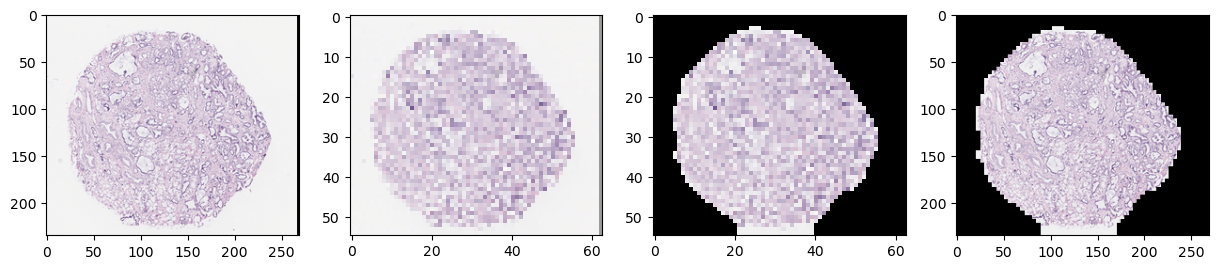

In [69]:
## Visualise mask
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(thumbnail)
axes[1].imshow(tile_map)
axes[2].imshow(tile_map_masked)
axes[3].imshow(thumbnail_masked)
plt.show()
plt.close()

In [70]:
############################################
## PATCH COORDINATES EXTRACTION FOR MODEL ##
############################################

## Adjust tile size if level is not 0
if level > 0: 
    ds_ = 4 * level
    model_tile_size = int(model_tile_size/ds_)

## Remove patches too close to the edges
tile_coordinates_new = []
for tile_coordinates_ in tile_coordinates:
    coords_0_lo = tile_coordinates_[0] + int(tissue_tile_size/2) - int(model_tile_size/2)
    coords_0_hi = tile_coordinates_[0] + int(tissue_tile_size/2) + int(model_tile_size/2)
    coords_1_lo = tile_coordinates_[1] + int(tissue_tile_size/2) - int(model_tile_size/2)
    coords_1_hi = tile_coordinates_[1] + int(tissue_tile_size/2) + int(model_tile_size/2)
    if (coords_0_lo > 0) & (coords_0_hi < canvas_size[1]) & (coords_1_lo > 0) & (coords_1_hi < canvas_size[0]):
        tile_coordinates_new += [[coords_0_lo, coords_1_lo]]

## Get patches closest to grid points
tile_coordinates = select_patches_on_grid(tile_coordinates_new, grid_spacing=int(model_tile_size/2))
print(f'Number of patches: {len(tile_coordinates)}')
      
#
###

Number of patches: 161


In [71]:
#################
## APPLY MODEL ##
#################

## Iterate through the patches
preds = []
for i in range(0, len(tile_coordinates), batch_size):
    batch_coords = tile_coordinates[i:i + batch_size]
    patches = slide_path_to_tiles_at_coordinates(wsi_path, batch_coords, model_tile_size, level)
    X = numpy_to_device(patches, device)
    with torch.no_grad():        
        for x in X:                
            preds_ = model(x) 
            preds_ = torch.sigmoid(preds_) * 255 # Logits to probabilities to [0, 255]
            preds_ = device_to_numpy(preds_, model_tile_size, model_tile_size)[0]
            if num_classes > 1:
                preds_ = np.argmax(preds_, axis=2).reshape(preds_.shape[0], preds_.shape[1], 1) # Only for multiple classes
            if downsample_preds > 1:
                preds_ = cv2.resize(preds_.astype('uint8'), (preds_.shape[1] // downsample_preds, preds_.shape[0] // downsample_preds))[:,:,None]
            preds.append(preds_)
    
#
###

In [72]:
############################
## REASSEMBLE PREDICTIONS ##
############################

## Assemble predictions
if downsample_preds > 1:
    rescaled_tile_coordinates = [[coords[0] // downsample_preds, coords[1] // downsample_preds] for coords in tile_coordinates]
    mask = reassemble_tiles(preds, rescaled_tile_coordinates, canvas_size[1] // downsample_preds, canvas_size[0] // downsample_preds)
else: 
    mask = reassemble_tiles(preds, tile_coordinates, canvas_size[1], canvas_size[0])
mask = mask[:,:,0].reshape(mask.shape[0], mask.shape[1], 1)
mask[:tissue_mask.shape[0], :tissue_mask.shape[1]] = mask[:tissue_mask.shape[0], :tissue_mask.shape[1]] * tissue_mask

#
###

In [73]:
#################
## POLISH MASK ##
#################

## Parameters
downsample_mask = 4 # Downscale factor
num_polish = 1 # Number of times to apply mask polish

## Binarise mask
mask = ((mask > 0)*1).astype('uint8')
mask = cv2.resize(mask, (int(mask.shape[1]/downsample_mask), int(mask.shape[0]/downsample_mask)))
mask = mask[:,:,None]

## Polish mask
for i in range(num_polish):
    mask = polish(mask)    

#
###

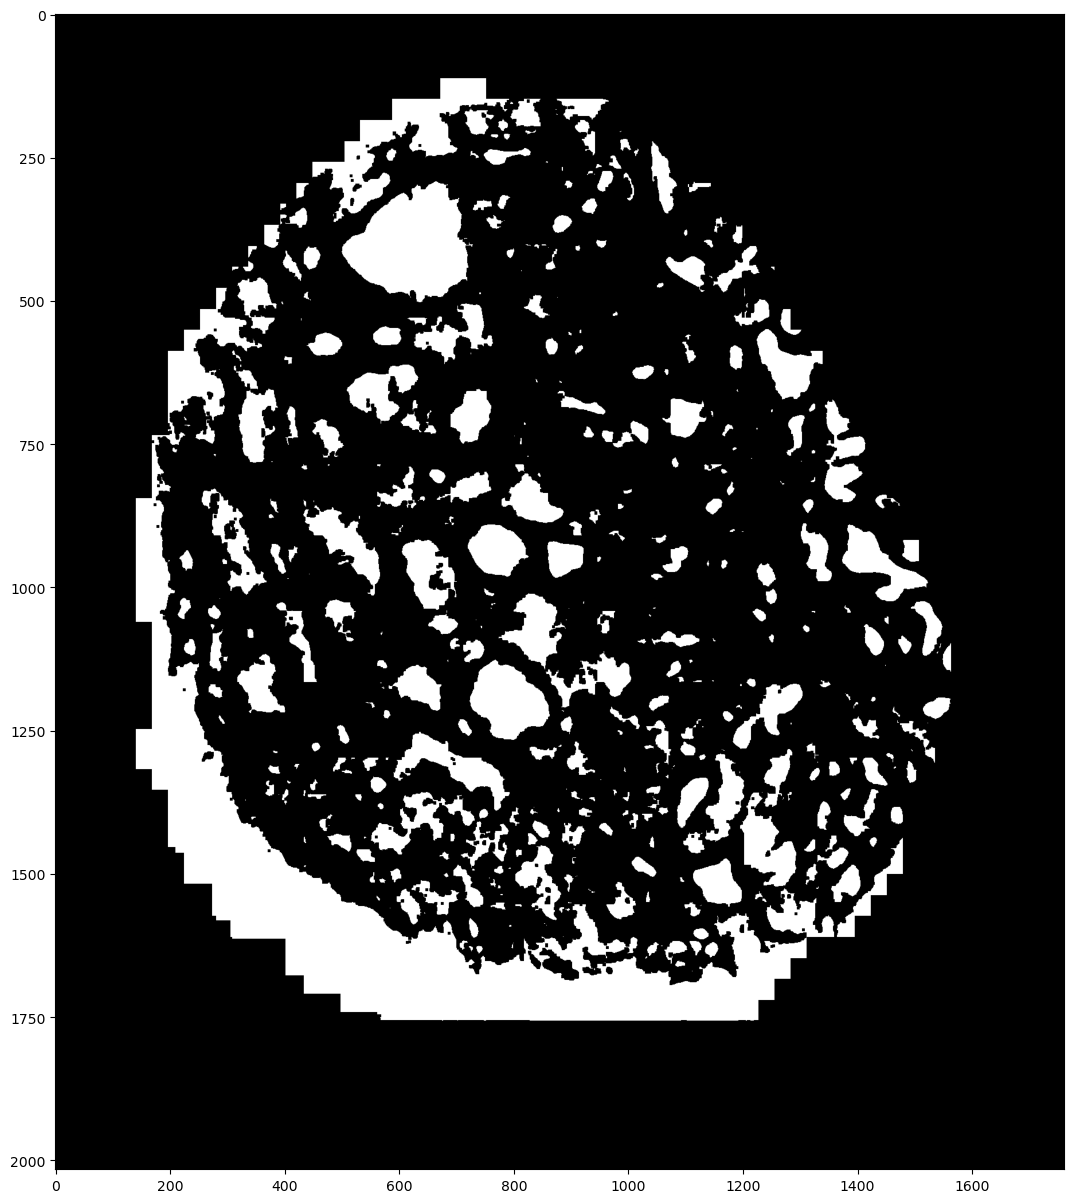

In [74]:
## Visualise
fig, axes = plt.subplots(1, 1, figsize=(15, 15))
axes.imshow(mask, cmap='gist_gray')
plt.show()
plt.close()


In [132]:
#####################
## EXTRACT OBJECTS ##
#####################

## Get objects
gland_coords = extract_object_pixels(mask)
print(len(gland_coords))

## Rescale coordinates to original size
rescaled_gland_coords = [coords * downsample_mask * downsample_preds for coords in gland_coords]

#
###

223


In [133]:
##################
## SAVE OBJECTS ##
##################

## Parameters
buffer = 200 # Minimum buffer distance in pixels between image boundary and bounding box of objects
dxy = 30 # Number of pixels increase in the bounding box of the objects
threshold = 1000

## Create a folder to store extracted object images    
os.makedirs(output_folder, exist_ok=True)
    
## Extract and save each object
objects = []
for i, coords in enumerate(rescaled_gland_coords):

    ## Discard small objects
    if len(coords) > (threshold // downsample_preds // downsample_preds):
        
        ## Get bounding box of the object
        x_min, y_min, x_max, y_max = get_bounding_box_square(coords)
    
        ## Discard object if overlaps tissue boundary
        if ((x_min - buffer) > 0) & ((x_max + buffer) < canvas_size[1] + 1) & ((y_min - buffer) > 0) & ((y_max + buffer) < canvas_size[0] + 1):

            ## Get object
            batch_coords = [[x_min - dxy, y_min - dxy]]
            tile_size = x_max - x_min + 2 * dxy
            object_img = slide_path_to_tiles_at_coordinates(wsi_path, batch_coords, tile_size, level)[0]
            object_img = cv2.cvtColor(object_img, cv2.COLOR_BGR2RGB) 
            objects += [object_img]
    
            ## Save the object image
            object_filename = os.path.join(output_folder, f'{os.path.basename(wsi_path)}_object_{i}.png')
            cv2.imwrite(object_filename, object_img)
    
#
###

print('')
print('Done')

KeyboardInterrupt: 